### BANK CUSTOMER CHURN PREDICTION
#### End-to-End Machine Learning Project

##### The goal of this notebook is to build a machine learning model that predicts whether a bank customer will leave the bank (churn).
##### Churn prediction is a common problem in banking because acquiring new customers is more expensive than retaining existing ones.

##### The dataset used: https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers

In [37]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [38]:
# LOAD DATASET
df = pd.read_csv("C:/AMOD/Extensive_bank/data/Churn.csv")

# Display first rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [39]:
# Show dataset dimensions
df.shape

(10000, 14)

In [40]:
# View summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [41]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [42]:
# CHECK MISSING VALUES

df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [43]:
# REMOVE NON-USEFUL COLUMNS
# These columns are identifiers and do not affect churn behaviour

df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


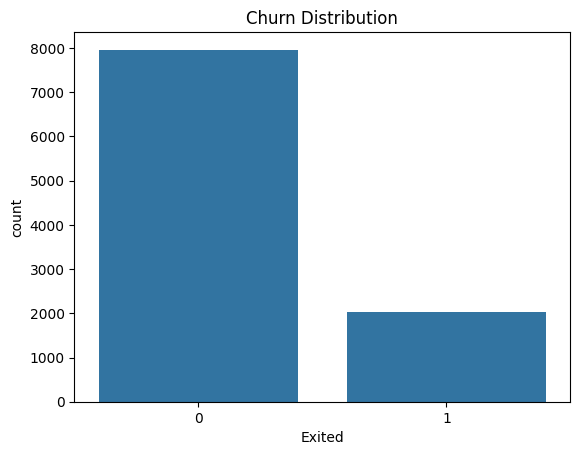

In [44]:
# EXPLORE TARGET VARIABLE
sns.countplot(x="Exited", data=df)

plt.title("Churn Distribution")
plt.show()

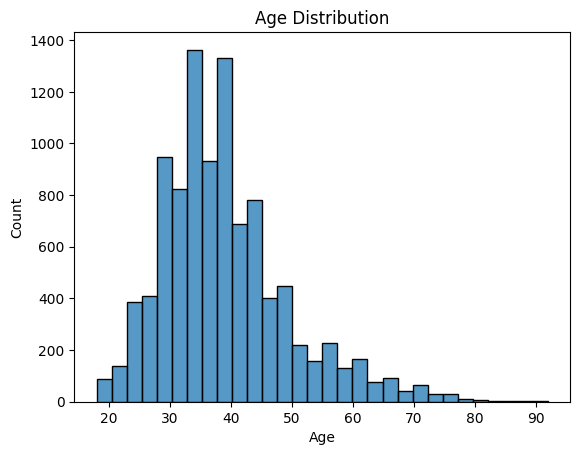

In [45]:
# Age Distribution
sns.histplot(df["Age"], bins=30)

plt.title("Age Distribution")
plt.show()

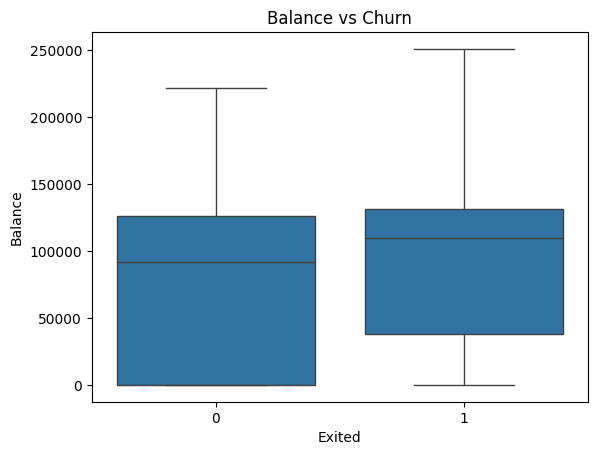

In [46]:
# Balance vs Churn to see if customers with higher salary churn more
sns.boxplot(x="Exited", y="Balance", data=df)

plt.title("Balance vs Churn")
plt.show()

In [47]:
# CONVERT CATEGORICAL VARIABLES - One Hot Encoding
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [48]:
# DEFINE FEATURES AND TARGET
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [49]:
# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
# Feature Scaling - StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
# Logistic Regression - Train
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

In [52]:
# Logistic Regression - Predict
y_pred = log_model.predict(X_test)

In [53]:
# Model Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.811


In [54]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

[[1543   64]
 [ 314   79]]


In [55]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



# Key Insights - Logistic Regression
The model performs very well at predicting customers who stay with the bank, but it struggles to identify customers who churn. Specifically, it only detects 20% of churned customers, meaning many churn cases are missed.

This issue is likely caused by class imbalance, where the dataset contains significantly more non-churned customers than churned customers.

In [56]:
# Random Forest - Train
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [57]:
# Random Forest - Predict
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8705


In [58]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_rf))

[[1553   54]
 [ 205  188]]


In [59]:
# Classification Report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.78      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



# Key Insights - Random Forest

The Random Forest model achieves 87% accuracy, performing very well for non-churned customers (recall 0.97) and better than Logistic Regression at detecting churned customers (recall 0.48 vs ~0.20).

Random Forest captures more complex patterns, improving precision and recall for churn, though some churn cases are still missed.

In [60]:
# Feature Importance
importance = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head()

,Feature,Importance
1,Age,0.237901
7,EstimatedSalary,0.146879
0,CreditScore,0.142729
3,Balance,0.140415
4,NumOfProducts,0.132104


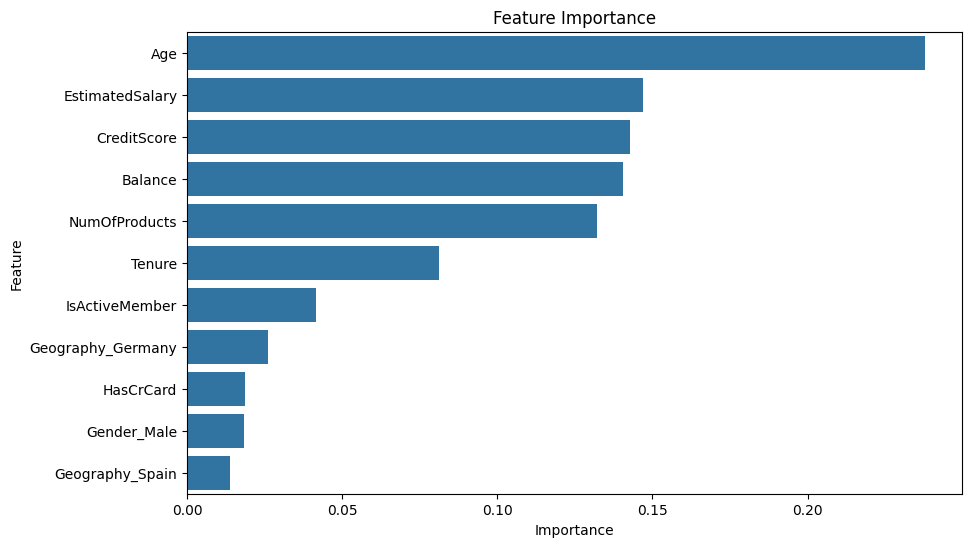

In [61]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance")
plt.show()

In [62]:
# Weighted Random Forest
rf_model_weighted = RandomForestClassifier(
    n_estimators=200,
    class_weight={0:1, 1:3},
    random_state=42
)
rf_model_weighted.fit(X_train, y_train)

# Predicted probabilities
y_prob = rf_model_weighted.predict_proba(X_test)[:,1]

# Adjust threshold for better churn recall
threshold = 0.3
y_pred_adjusted = (y_prob > threshold).astype(int)

# Evaluate

print("Accuracy:", accuracy_score(y_test, y_pred_adjusted))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_adjusted))
print("Classification Report:\n", classification_report(y_test, y_pred_adjusted))

Accuracy: 0.8375
Confusion Matrix:
 [[1416  191]
 [ 134  259]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.90      1607
           1       0.58      0.66      0.61       393

    accuracy                           0.84      2000
   macro avg       0.74      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



# Key Insights - Random Forest

The weighted Random Forest model assigns a higher weight to churned customers to address the dataset’s class imbalance. This forces the model to pay more attention to the minority class during training, improving its ability to detect customers likely to churn.

As a result:
1. Churn recall increased from 0.48 → 0.66
2. Overall accuracy slightly decreased from 87% → 83.8%

### Justification of tradeoff:
In churn prediction, identifying at-risk customers is more important than maximizing overall accuracy, because false negatives (missed churns) are costly for banks. Sacrificing a small portion of accuracy to capture more churners is strategically beneficial for customer retention initiatives.

# Business Insights

1. Improved churn detection: The weighted Random Forest identifies 2/3 of churned customers, helping banks target at-risk customers.

2. Strategic retention: Features like Age, Salary, and Credit Score reveal which customers are most likely to churn, enabling personalized retention campaigns.

3. Balanced tradeoff: Slight reduction in overall accuracy (87% → 83.8%) is acceptable because catching more churned customers has higher business value than maximizing overall accuracy.

4. Actionable recommendations: The bank can prioritize churn prevention offers to customers flagged as high risk by the model.

In [63]:
# Saving the model

joblib.dump(rf_model, "C:/AMOD/Extensive_bank/models/churn_model.pkl")

['C:/AMOD/Extensive_bank/models/churn_model.pkl']